<a href="https://colab.research.google.com/github/teresici/Tutorials_Cosmoverse/blob/main/OGLE_period_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# OGLE Variable Stars: Period Determination and Sampling Effects

This notebook shows how to:

- Download OGLE light curves directly from the web
- Measure sampling properties and cadence
- Compute periods using different methods
- Compare derived periods with OGLE catalog values
- Study the impact of sparse vs dense sampling

Included classes:
- RR Lyrae
- Cepheids
- Delta Scuti
- Mira / Long-period variables


In [3]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from astropy.timeseries import LombScargle
from urllib.request import urlopen
from io import StringIO

plt.rcParams["figure.figsize"] = (8,5)



## Reading OGLE light curves directly from the web


In [4]:

def read_ogle_lightcurve(url):
    txt = urlopen(url).read().decode()

    df = pd.read_csv(
        StringIO(txt),
        delim_whitespace=True,
        names=["hjd", "mag", "err"],
        comment="#"
    )

    return df.dropna()



## Sampling diagnostics

We compute:
- number of observations
- total baseline
- median cadence
- cadence distribution


In [5]:

def sampling_statistics(df):

    t = np.sort(df["hjd"].values)

    baseline = t.max() - t.min()
    cadence = np.diff(t)

    stats = {
        "N_points": len(t),
        "Baseline_days": baseline,
        "Median_cadence_days": np.median(cadence),
        "Mean_cadence_days": np.mean(cadence)
    }

    return stats, cadence



## Lomb–Scargle periodogram


In [6]:

def lomb_scargle_period(df, min_period=0.03, max_period=100):

    t = df["hjd"].values
    y = df["mag"].values
    dy = df["err"].values

    frequency, power = LombScargle(t, y, dy).autopower(
        minimum_frequency=1/max_period,
        maximum_frequency=1/min_period,
        samples_per_peak=10
    )

    best_frequency = frequency[np.argmax(power)]
    best_period = 1 / best_frequency

    return best_period, frequency, power



## Simple Phase Dispersion Minimization (PDM-like estimator)

This is a simplified implementation for teaching purposes.


In [7]:

def simple_pdm(df, periods):

    t = df["hjd"].values
    y = df["mag"].values

    theta_values = []

    for P in periods:

        phase = (t / P) % 1

        order = np.argsort(phase)

        phase = phase[order]
        y_sorted = y[order]

        bins = np.array_split(y_sorted, 10)

        variances = [np.var(b) for b in bins if len(b) > 1]

        theta = np.mean(variances)

        theta_values.append(theta)

    theta_values = np.array(theta_values)

    best_period = periods[np.argmin(theta_values)]

    return best_period, theta_values



## Phase folding


In [9]:

def phase_fold(df, period):

    folded = df.copy()

    folded["phase"] = (folded["hjd"] / period) % 1

    return folded.sort_values("phase")



## Example: RR Lyrae star


In [10]:

url = "https://www.astrouw.edu.pl/ogle/ogle4/OCVS/lmc/rrlyr/phot/I/OGLE-LMC-RRLYR-00001.dat"

ogle_period = 0.634

df = read_ogle_lightcurve(url)

stats, cadence = sampling_statistics(df)

print(stats)


{'N_points': 403, 'Baseline_days': np.float64(2232.9716499999995), 'Median_cadence_days': np.float64(2.969174999999723), 'Mean_cadence_days': np.float64(5.554655845771143)}


/tmp/ipykernel_1144/2653409985.py:4: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(


In [11]:
print(df)

            hjd     mag    err
0    5262.50439  18.634  0.051
1    5264.50622  18.587  0.040
2    5265.59114  18.975  0.064
3    5266.50252  18.754  0.068
4    5267.50194  18.979  0.075
..          ...     ...    ...
398  7458.59769  18.839  0.044
399  7465.50031  18.821  0.042
400  7471.53512  18.487  0.054
401  7475.51161  18.780  0.041
402  7495.47604  19.002  0.077

[403 rows x 3 columns]


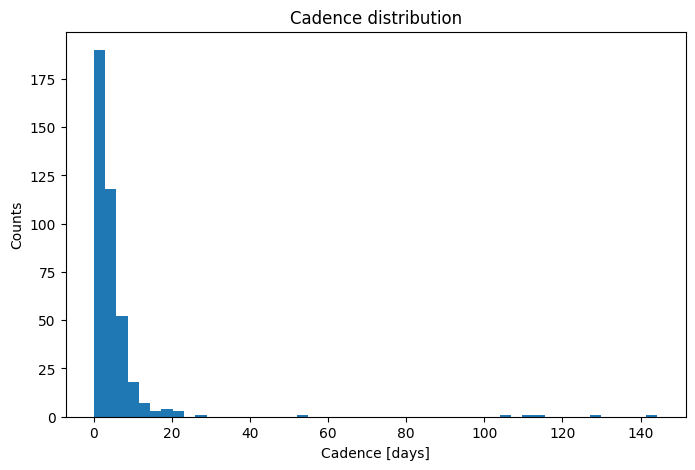

In [12]:

plt.hist(cadence, bins=50)

plt.xlabel("Cadence [days]")
plt.ylabel("Counts")
plt.title("Cadence distribution")

plt.show()


In [13]:

best_ls_period, frequency, power = lomb_scargle_period(
    df,
    min_period=0.2,
    max_period=1.2
)

print("OGLE catalog period:", ogle_period)
print("Lomb–Scargle period:", best_ls_period)


OGLE catalog period: 0.634
Lomb–Scargle period: 0.6347438777949495


In [14]:

periods = np.linspace(0.2, 1.2, 1000)

best_pdm_period, theta_values = simple_pdm(df, periods)

print("PDM-like period:", best_pdm_period)


PDM-like period: 1.117917917917918


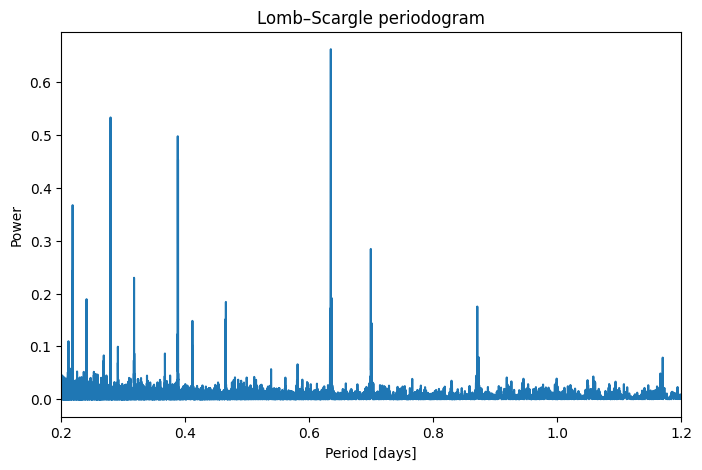

In [15]:

plt.plot(1/frequency, power)

plt.xlim(0.2, 1.2)

plt.xlabel("Period [days]")
plt.ylabel("Power")
plt.title("Lomb–Scargle periodogram")

plt.show()


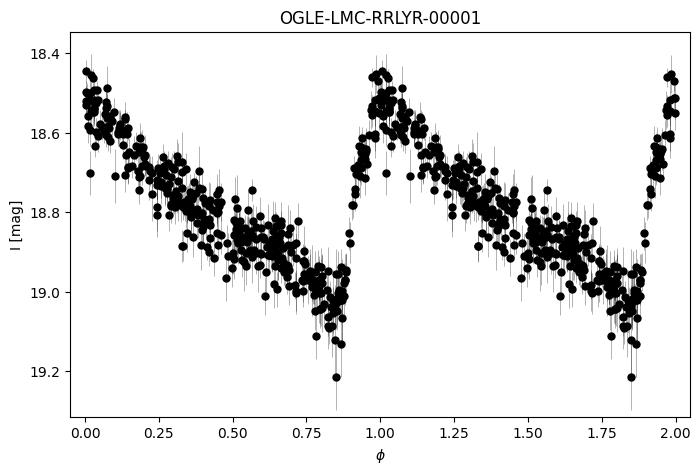

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# valori OGLE per OGLE-LMC-RRLYR-00001
P = 0.6347521
T0 = 6000.13200   # time of maximum brightness, HJD - 2450000

hjd = df["hjd"].to_numpy(dtype=float)
mag = df["mag"].to_numpy(dtype=float)
err = df["err"].to_numpy(dtype=float)

phase = ((hjd - T0) / P) % 1

idx = np.argsort(phase)

phase = phase[idx]
mag = mag[idx]
err = err[idx]

phase12 = np.concatenate((phase, phase + 1))
mag12 = np.concatenate((mag, mag))
err12 = np.concatenate((err, err))

fig, ax = plt.subplots(figsize=(8, 5))

ax.scatter(phase12, mag12, s=25, color="black")
ax.errorbar(
    phase12,
    mag12,
    yerr=err12,
    fmt="none",
    ecolor="black",
    alpha=0.3,
    elinewidth=0.7
)

ax.set_xlim(-0.05, 2.05)
ax.set_ylim(np.max(mag12) + 0.1, np.min(mag12) - 0.1)

ax.set_xlabel(r"$\phi$")
ax.set_ylabel("I [mag]")
ax.set_title("OGLE-LMC-RRLYR-00001")

plt.show()


## Suggested exercises

1. Compare RR Lyrae and Cepheids
2. Compare densely sampled and sparsely Anomalous Cepheids
3. Study aliasing effects
4. Compare Lomb–Scargle and PDM
5. Explore long-period variables (Mira stars)


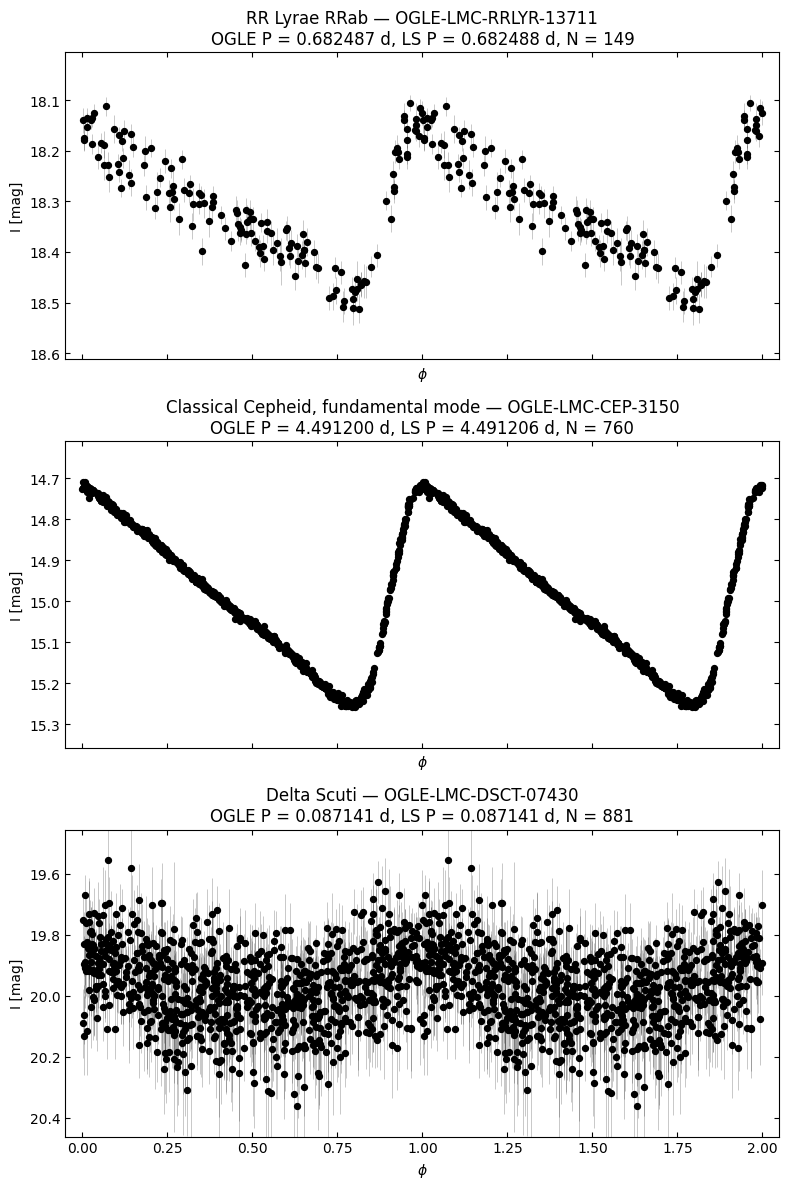

,class,star_id,N_points,baseline_days,median_cadence_days,OGLE_period_days,LS_period_days,LS_minus_OGLE_days,phot_url
0,RR Lyrae RRab,OGLE-LMC-RRLYR-13711,149,2117.13554,4.954535,0.682487,0.682488,8.014163e-07,https://www.astrouw.edu.pl/ogle/ogle4/OCVS/lmc...
1,"Classical Cepheid, fundamental mode",OGLE-LMC-CEP-3150,760,2246.80699,1.024740,4.491200,4.491206,6.465678e-06,https://www.astrouw.edu.pl/ogle/ogle4/OCVS/lmc...
2,Delta Scuti,OGLE-LMC-DSCT-07430,881,3660.95881,1.050755,0.087141,0.087141,-1.921508e-07,https://www.astrouw.edu.pl/ogle/ogle4/OCVS/lmc...


In [32]:
# ============================================================
# EXERCISE 1 — Compare RR Lyrae, Cepheid, and Delta Scuti
# One-cell complete version
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from urllib.request import urlopen
from io import StringIO
from astropy.timeseries import LombScargle

# ------------------------------------------------------------
# OGLE examples
# ------------------------------------------------------------

EXERCISE1_CLASSES = [
    {
        "label": "RR Lyrae RRab",
        "catalog_url": "https://www.astrouw.edu.pl/ogle/ogle4/OCVS/lmc/rrlyr/RRab.dat",
        "phot_base_url": "https://www.astrouw.edu.pl/ogle/ogle4/OCVS/lmc/rrlyr/phot/I",
        "id_slice": (0, 20),
        "period_slice": (37, 46),
        "epoch_slice": (58, 68),
        "amp_slice": (70, 75),
        "min_period": 0.35,
        "max_period": 1.0,
    },
    {
        "label": "Classical Cepheid, fundamental mode",
        "catalog_url": "https://www.astrouw.edu.pl/ogle/ogle4/OCVS/lmc/cep/cepF.dat",
        "phot_base_url": "https://www.astrouw.edu.pl/ogle/ogle4/OCVS/lmc/cep/phot/I",
        "id_slice": (0, 17),
        "period_slice": (33, 44),
        "epoch_slice": (56, 66),
        "amp_slice": (68, 73),
        "min_period": 0.5,
        "max_period": 100.0,
    },
    {
        "label": "Delta Scuti",
        "catalog_url": "https://www.astrouw.edu.pl/ogle/ogle4/OCVS/lmc/dsct/dsct.dat",
        "phot_base_url": "https://www.astrouw.edu.pl/ogle/ogle4/OCVS/lmc/dsct/phot/I",
        "id_slice": (0, 19),
        "period_slice": (36, 46),
        "epoch_slice": (59, 69),
        "amp_slice": (71, 76),
        "min_period": 0.015,
        "max_period": 0.35,
    },
]

RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)

# ------------------------------------------------------------
# Helper functions
# ------------------------------------------------------------

def read_text_from_url(url):
    return urlopen(url).read().decode()


def read_ogle_lightcurve(url):
    df = pd.read_csv(
        url,
        sep=r"\s+",
        names=["hjd", "mag", "err"],
        comment="#"
    )

    df = df.dropna()
    df = df.sort_values("hjd").reset_index(drop=True)

    return df


def parse_catalog_line(line, cfg):
    s0, s1 = cfg["id_slice"]
    p0, p1 = cfg["period_slice"]
    t0, t1 = cfg["epoch_slice"]
    a0, a1 = cfg["amp_slice"]

    star_id = line[s0:s1].strip()
    period = float(line[p0:p1])
    epoch = float(line[t0:t1])

    amp_text = line[a0:a1].strip()
    amplitude = float(amp_text) if amp_text != "" else np.nan

    return star_id, period, epoch, amplitude


def choose_random_valid_star(cfg, max_trials=200):
    txt = read_text_from_url(cfg["catalog_url"])
    lines = [line for line in txt.splitlines() if line.strip()]

    order = rng.permutation(len(lines))

    for idx in order[:max_trials]:
        line = lines[idx]

        try:
            star_id, period, epoch, amplitude = parse_catalog_line(line, cfg)
            phot_url = f"{cfg['phot_base_url']}/{star_id}.dat"

            df = read_ogle_lightcurve(phot_url)

            if len(df) > 30:
                return {
                    "label": cfg["label"],
                    "star_id": star_id,
                    "period_ogle": period,
                    "epoch_ogle": epoch,
                    "amplitude_I": amplitude,
                    "phot_url": phot_url,
                    "min_period": cfg["min_period"],
                    "max_period": cfg["max_period"],
                    "df": df,
                }

        except Exception:
            continue

    raise RuntimeError(f"No valid star found for {cfg['label']}.")


def sampling_statistics(df):
    hjd = np.sort(df["hjd"].to_numpy(dtype=float))
    cadence = np.diff(hjd)

    return {
        "N_points": len(hjd),
        "baseline_days": hjd.max() - hjd.min(),
        "median_cadence_days": np.median(cadence),
        "mean_cadence_days": np.mean(cadence),
        "max_gap_days": np.max(cadence),
    }


def lomb_scargle_period(df, min_period, max_period):
    hjd = df["hjd"].to_numpy(dtype=float)
    mag = df["mag"].to_numpy(dtype=float)
    err = df["err"].to_numpy(dtype=float)

    mag_centered = mag - np.mean(mag)

    frequency, power = LombScargle(hjd, mag_centered, err).autopower(
        minimum_frequency=1 / max_period,
        maximum_frequency=1 / min_period,
        samples_per_peak=20
    )

    best_period = 1 / frequency[np.argmax(power)]

    return best_period, frequency, power


def phase_fold(df, period, epoch):
    hjd = df["hjd"].to_numpy(dtype=float)
    mag = df["mag"].to_numpy(dtype=float)
    err = df["err"].to_numpy(dtype=float)

    phase = ((hjd - epoch) / period) % 1

    idx = np.argsort(phase)

    phase = phase[idx]
    mag = mag[idx]
    err = err[idx]

    phase2 = np.concatenate([phase, phase + 1])
    mag2 = np.concatenate([mag, mag])
    err2 = np.concatenate([err, err])

    return phase2, mag2, err2


def plot_folded(ax, df, period, epoch, title):
    phase2, mag2, err2 = phase_fold(df, period, epoch)

    ax.scatter(phase2, mag2, s=18, color="black", zorder=3)
    ax.errorbar(
        phase2,
        mag2,
        yerr=err2,
        fmt="none",
        ecolor="black",
        alpha=0.25,
        elinewidth=0.6,
        zorder=2
    )

    ax.set_xlim(-0.05, 2.05)
    ax.set_ylim(np.max(mag2) + 0.1, np.min(mag2) - 0.1)

    ax.set_xlabel(r"$\phi$")
    ax.set_ylabel("I [mag]")
    ax.set_title(title)

    ax.tick_params(direction="in", bottom=True, top=True, left=True, right=True)


# ------------------------------------------------------------
# Run exercise
# ------------------------------------------------------------

selected = []

for cfg in EXERCISE1_CLASSES:
    star = choose_random_valid_star(cfg)
    selected.append(star)

summary_rows = []

fig, axes = plt.subplots(len(selected), 1, figsize=(8, 12), sharex=True)

for ax, star in zip(axes, selected):
    df = star["df"]

    stats = sampling_statistics(df)

    ls_period, frequency, power = lomb_scargle_period(
        df,
        min_period=star["min_period"],
        max_period=star["max_period"]
    )

    summary_rows.append({
        "class": star["label"],
        "star_id": star["star_id"],
        "N_points": stats["N_points"],
        "baseline_days": stats["baseline_days"],
        "median_cadence_days": stats["median_cadence_days"],
        "OGLE_period_days": star["period_ogle"],
        "LS_period_days": ls_period,
        "LS_minus_OGLE_days": ls_period - star["period_ogle"],
        "phot_url": star["phot_url"],
    })

    title = (
        f"{star['label']} — {star['star_id']}\n"
        f"OGLE P = {star['period_ogle']:.6f} d, "
        f"LS P = {ls_period:.6f} d, "
        f"N = {stats['N_points']}"
    )

    plot_folded(
        ax,
        df,
        period=star["period_ogle"],
        epoch=star["epoch_ogle"],
        title=title
    )

plt.tight_layout()
plt.show()

exercise1_summary = pd.DataFrame(summary_rows)

display(exercise1_summary)

In [27]:
ACEP_F_EXAMPLE = {
    "label": "Anomalous Cepheid, fundamental mode",
    "catalog_url": "https://www.astrouw.edu.pl/ogle/ogle4/OCVS/lmc/acep/acepF.dat",
    "phot_base_url": "https://www.astrouw.edu.pl/ogle/ogle4/OCVS/lmc/acep/phot/I",
    "id_slice": (0, 17),
    "period_slice": (33, 43),
    "epoch_slice": (55, 65),
    "amp_slice": (67, 72),
    "min_period": 0.3,
    "max_period": 5.0,
}

def phase_coverage_score(df, period, epoch, n_bins=20):
    hjd = df["hjd"].to_numpy(dtype=float)
    phase = ((hjd - epoch) / period) % 1

    counts, _ = np.histogram(phase, bins=np.linspace(0, 1, n_bins + 1))

    occupied_bins = np.sum(counts > 0)
    empty_bins = np.sum(counts == 0)

    phase_sorted = np.sort(phase)
    gaps = np.diff(np.concatenate([phase_sorted, phase_sorted[:1] + 1]))
    max_phase_gap = np.max(gaps)

    score = occupied_bins / n_bins - max_phase_gap

    return {
        "N_points": len(df),
        "occupied_bins": occupied_bins,
        "empty_bins": empty_bins,
        "max_phase_gap": max_phase_gap,
        "score": score,
    }


def read_acep_catalog(example, max_objects=None):
    txt = read_text_from_url(example["catalog_url"])
    lines = [line for line in txt.splitlines() if line.strip()]

    if max_objects is not None:
        lines = lines[:max_objects]

    records = []

    for line in lines:
        s0, s1 = example["id_slice"]
        p0, p1 = example["period_slice"]
        t0, t1 = example["epoch_slice"]
        a0, a1 = example["amp_slice"]

        star_id = line[s0:s1].strip()

        try:
            period = float(line[p0:p1])
            epoch = float(line[t0:t1])
            amp = float(line[a0:a1])
        except:
            continue

        records.append({
            "star_id": star_id,
            "period_ogle": period,
            "epoch_ogle": epoch,
            "amplitude_I": amp,
            "phot_url": f"{example['phot_base_url']}/{star_id}.dat",
        })

    return records

def find_best_and_worst_sampled_acep(example, max_objects=80, n_bins=20):

    records = read_acep_catalog(example, max_objects=max_objects)

    rows = []

    for rec in records:
        try:
            df = read_ogle_lightcurve(rec["phot_url"])
            cov = phase_coverage_score(
                df,
                period=rec["period_ogle"],
                epoch=rec["epoch_ogle"],
                n_bins=n_bins
            )

            rows.append({
                **rec,
                **cov
            })

        except Exception as e:
            pass

    table = pd.DataFrame(rows)

    table = table.sort_values("score", ascending=False).reset_index(drop=True)

    good = table.iloc[0]
    poor = table.iloc[-1]

    return table, good, poor

acep_sampling_table, good_acep, poor_acep = find_best_and_worst_sampled_acep(
    ACEP_F_EXAMPLE,
    max_objects=80,
    n_bins=20
)

display(acep_sampling_table[[
    "star_id",
    "N_points",
    "period_ogle",
    "occupied_bins",
    "empty_bins",
    "max_phase_gap",
    "score"
]].head(10))

display(acep_sampling_table[[
    "star_id",
    "N_points",
    "period_ogle",
    "occupied_bins",
    "empty_bins",
    "max_phase_gap",
    "score"
]].tail(10))


def make_result_from_row(row, label):
    df = read_ogle_lightcurve(row["phot_url"])

    stats, _ = sampling_statistics(df)

    return {
        "record": {
            "label": label,
            "star_id": row["star_id"],
            "period_ogle": row["period_ogle"],
            "epoch_ogle": row["epoch_ogle"],
            "amplitude_I": row["amplitude_I"],
            "phot_url": row["phot_url"],
            "min_period": ACEP_F_EXAMPLE["min_period"],
            "max_period": ACEP_F_EXAMPLE["max_period"],
        },
        "df": df,
        "full_stats": stats,
    }

result_acep_good = make_result_from_row(
    good_acep,
    "well phase-sampled anomalous Cepheid"
)

result_acep_poor = make_result_from_row(
    poor_acep,
    "poorly phase-sampled anomalous Cepheid"
)

/tmp/ipykernel_1144/2653409985.py:4: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(
/tmp/ipykernel_1144/2653409985.py:4: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(
/tmp/ipykernel_1144/2653409985.py:4: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(
/tmp/ipykernel_1144/2653409985.py:4: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(
/tmp/ipykernel_1144/2653409985.py:4: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(
/tmp/

,star_id,N_points,period_ogle,occupied_bins,empty_bins,max_phase_gap,score
0,OGLE-LMC-ACEP-055,692,1.606669,20,0,0.007140,0.992860
1,OGLE-LMC-ACEP-044,723,1.308523,20,0,0.007890,0.992110
2,OGLE-LMC-ACEP-034,708,0.734300,20,0,0.008035,0.991965
3,OGLE-LMC-ACEP-060,663,1.275734,20,0,0.008106,0.991894
4,OGLE-LMC-ACEP-053,691,1.888107,20,0,0.008329,0.991671
5,OGLE-LMC-ACEP-063,713,0.893028,20,0,0.008408,0.991592
6,OGLE-LMC-ACEP-049,712,0.644801,20,0,0.008594,0.991406
7,OGLE-LMC-ACEP-004,754,1.861846,20,0,0.008651,0.991349
8,OGLE-LMC-ACEP-007,750,0.896400,20,0,0.008730,0.991270
9,OGLE-LMC-ACEP-017,795,0.929997,20,0,0.008784,0.991216


,star_id,N_points,period_ogle,occupied_bins,empty_bins,max_phase_gap,score
69,OGLE-LMC-ACEP-085,149,0.915632,20,0,0.033552,0.966448
70,OGLE-LMC-ACEP-087,118,1.480813,20,0,0.038176,0.961824
71,OGLE-LMC-ACEP-106,122,1.453434,20,0,0.039998,0.960002
72,OGLE-LMC-ACEP-102,125,1.217524,20,0,0.042336,0.957664
73,OGLE-LMC-ACEP-108,120,0.814858,19,1,0.055617,0.894383
74,OGLE-LMC-ACEP-066,55,1.040071,19,1,0.082086,0.867914
75,OGLE-LMC-ACEP-038,53,1.335225,19,1,0.083216,0.866784
76,OGLE-LMC-ACEP-019,65,0.909406,18,2,0.121667,0.778333
77,OGLE-LMC-ACEP-054,52,0.980216,16,4,0.082220,0.717780
78,OGLE-LMC-ACEP-011,69,0.998657,9,11,0.380565,0.069435


/tmp/ipykernel_1144/2653409985.py:4: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(
/tmp/ipykernel_1144/2653409985.py:4: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(


Good phase sampling:
star_id          OGLE-LMC-ACEP-055
N_points                       692
period_ogle               1.606669
occupied_bins                   20
empty_bins                       0
max_phase_gap              0.00714
score                      0.99286
Name: 0, dtype: object


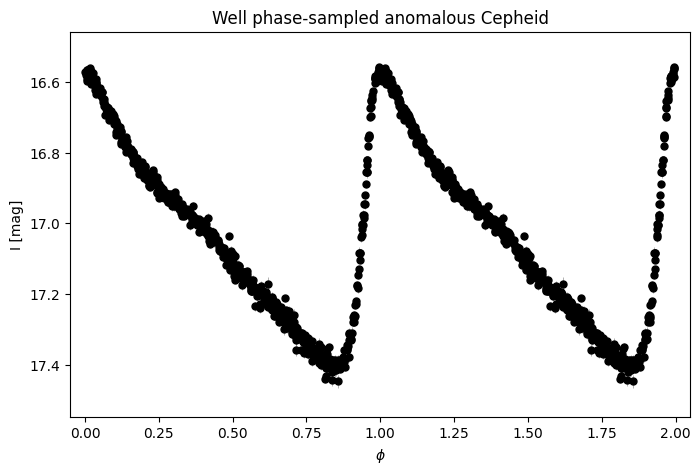

Poor phase sampling:
star_id          OGLE-LMC-ACEP-011
N_points                        69
period_ogle               0.998657
occupied_bins                    9
empty_bins                      11
max_phase_gap             0.380565
score                     0.069435
Name: 78, dtype: object


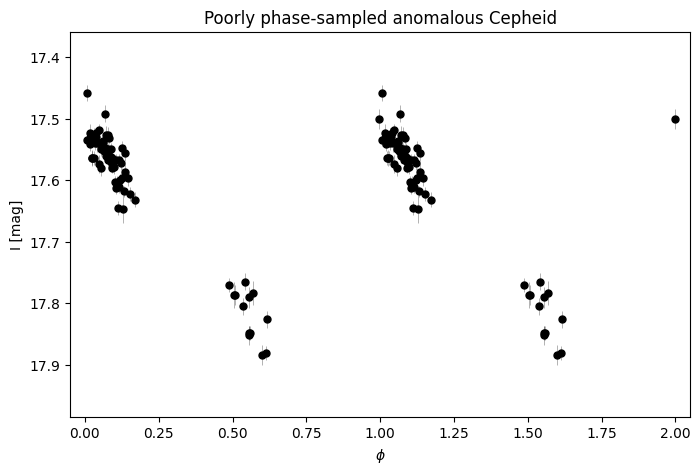

In [30]:
print("Good phase sampling:")
print(good_acep[["star_id", "N_points", "period_ogle", "occupied_bins", "empty_bins", "max_phase_gap", "score"]])

def plot_folded_lightcurve(df, period, epoch, amplitude, title):
    hjd = df["hjd"].to_numpy(dtype=float)
    mag = df["mag"].to_numpy(dtype=float)
    err = df["err"].to_numpy(dtype=float)

    phase = ((hjd - epoch) / period) % 1

    idx = np.argsort(phase)

    phase = phase[idx]
    mag = mag[idx]
    err = err[idx]

    phase12 = np.concatenate((phase, phase + 1))
    mag12 = np.concatenate((mag, mag))
    err12 = np.concatenate((err, err))

    fig, ax = plt.subplots(figsize=(8, 5))

    ax.scatter(phase12, mag12, s=25, color="black")
    ax.errorbar(
        phase12,
        mag12,
        yerr=err12,
        fmt="none",
        ecolor="black",
        alpha=0.3,
        elinewidth=0.7
    )

    ax.set_xlim(-0.05, 2.05)
    ax.set_ylim(np.max(mag12) + 0.1, np.min(mag12) - 0.1)

    ax.set_xlabel(r"$\phi$")
    ax.set_ylabel("I [mag]")
    ax.set_title(title)

    plt.show()

plot_folded_lightcurve(
    result_acep_good["df"],
    period=result_acep_good["record"]["period_ogle"],
    epoch=result_acep_good["record"]["epoch_ogle"],
    amplitude=result_acep_good["record"]["amplitude_I"],
    title="Well phase-sampled anomalous Cepheid"
)

print("Poor phase sampling:")
print(poor_acep[["star_id", "N_points", "period_ogle", "occupied_bins", "empty_bins", "max_phase_gap", "score"]])

plot_folded_lightcurve(
    result_acep_poor["df"],
    period=result_acep_poor["record"]["period_ogle"],
    epoch=result_acep_poor["record"]["epoch_ogle"],
    amplitude=result_acep_poor["record"]["amplitude_I"],
    title="Poorly phase-sampled anomalous Cepheid"
)

def compare_two_acep_sampling(result_good, result_poor):

    rows = []

    for name, result in [
        ("good phase sampling", result_good),
        ("poor phase sampling", result_poor),
    ]:
        rec = result["record"]
        df = result["df"]

        ls_period, freq, power = lomb_scargle_period(
            df,
            rec["min_period"],
            rec["max_period"]
        )

        pdm_period, pdm_grid, theta = pdm_refine_period(
            df,
            center_period=ls_period
        )

        cov = phase_coverage_score(
            df,
            period=rec["period_ogle"],
            epoch=rec["epoch_ogle"],
            n_bins=20
        )

        rows.append({
            "case": name,
            "star_id": rec["star_id"],
            "N_points": len(df),
            "occupied_bins": cov["occupied_bins"],
            "empty_bins": cov["empty_bins"],
            "max_phase_gap": cov["max_phase_gap"],
            "OGLE_period": rec["period_ogle"],
            "LS_period": ls_period,
            "PDM_period": pdm_period,
            "LS_minus_OGLE": ls_period - rec["period_ogle"],
            "PDM_minus_OGLE": pdm_period - rec["period_ogle"],
        })

    return pd.DataFrame(rows)

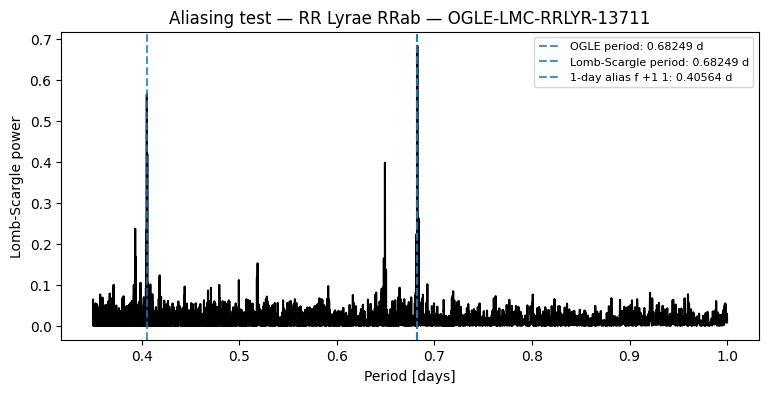

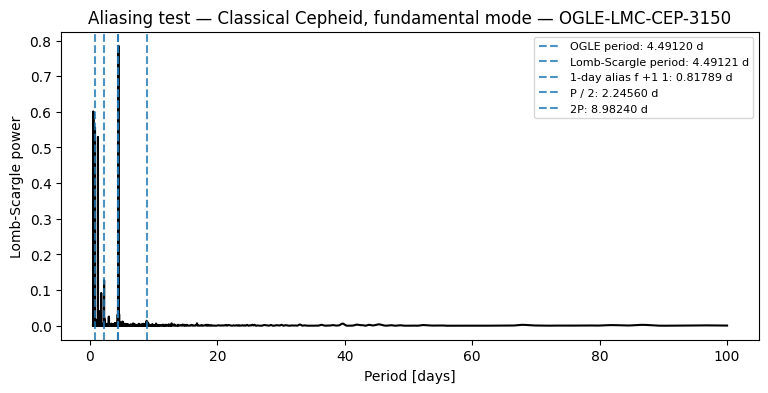

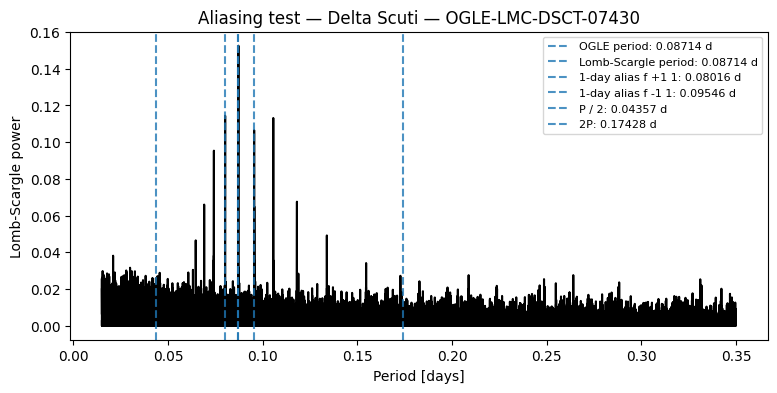

,class,star_id,alias_name,frequency_cycles_per_day,period_days,inside_search_range
0,RR Lyrae RRab,OGLE-LMC-RRLYR-13711,OGLE period,1.465229,0.682487,True
1,RR Lyrae RRab,OGLE-LMC-RRLYR-13711,Lomb-Scargle period,1.465228,0.682488,True
2,RR Lyrae RRab,OGLE-LMC-RRLYR-13711,1-day alias f +1 1,2.465229,0.405642,True
3,RR Lyrae RRab,OGLE-LMC-RRLYR-13711,1-day alias f -1 1,0.465229,2.149477,False
4,RR Lyrae RRab,OGLE-LMC-RRLYR-13711,P / 2,2.930459,0.341243,False
5,RR Lyrae RRab,OGLE-LMC-RRLYR-13711,2P,0.732615,1.364974,False
6,"Classical Cepheid, fundamental mode",OGLE-LMC-CEP-3150,OGLE period,0.222658,4.491200,True
7,"Classical Cepheid, fundamental mode",OGLE-LMC-CEP-3150,Lomb-Scargle period,0.222657,4.491206,True
8,"Classical Cepheid, fundamental mode",OGLE-LMC-CEP-3150,1-day alias f +1 1,1.222658,0.817890,True
9,"Classical Cepheid, fundamental mode",OGLE-LMC-CEP-3150,P / 2,0.445315,2.245600,True


In [33]:
# ============================================================
# EXERCISE 3 — Aliasing effects
# One-cell version
# Requires: selected, lomb_scargle_period
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

alias_rows = []

for star in selected:

    df = star["df"]

    P_ogle = star["period_ogle"]
    f_ogle = 1 / P_ogle

    ls_period, frequency, power = lomb_scargle_period(
        df,
        min_period=star["min_period"],
        max_period=star["max_period"]
    )

    periods = 1 / frequency
    order = np.argsort(periods)

    aliases = []

    aliases.append({
        "name": "OGLE period",
        "frequency": f_ogle,
        "period": P_ogle
    })

    aliases.append({
        "name": "Lomb-Scargle period",
        "frequency": 1 / ls_period,
        "period": ls_period
    })

    # 1-day aliases: f_alias = f +/- 1 cycle/day
    for sign in [+1, -1]:
        f_alias = f_ogle + sign * 1.0

        if f_alias > 0:
            aliases.append({
                "name": f"1-day alias f {sign:+d} 1",
                "frequency": f_alias,
                "period": 1 / f_alias
            })

    # harmonic aliases
    aliases.append({
        "name": "P / 2",
        "frequency": 2 * f_ogle,
        "period": P_ogle / 2
    })

    aliases.append({
        "name": "2P",
        "frequency": 0.5 * f_ogle,
        "period": 2 * P_ogle
    })

    fig, ax = plt.subplots(figsize=(9, 4))

    ax.plot(periods[order], power[order], color="black")

    for alias in aliases:
        p = alias["period"]

        if star["min_period"] <= p <= star["max_period"]:
            ax.axvline(
                p,
                linestyle="--",
                alpha=0.8,
                label=f"{alias['name']}: {p:.5f} d"
            )

    ax.set_xlabel("Period [days]")
    ax.set_ylabel("Lomb-Scargle power")
    ax.set_title(f"Aliasing test — {star['label']} — {star['star_id']}")
    ax.legend(fontsize=8)

    plt.show()

    for alias in aliases:
        alias_rows.append({
            "class": star["label"],
            "star_id": star["star_id"],
            "alias_name": alias["name"],
            "frequency_cycles_per_day": alias["frequency"],
            "period_days": alias["period"],
            "inside_search_range": (
                star["min_period"] <= alias["period"] <= star["max_period"]
            )
        })

alias_table = pd.DataFrame(alias_rows)

display(alias_table)

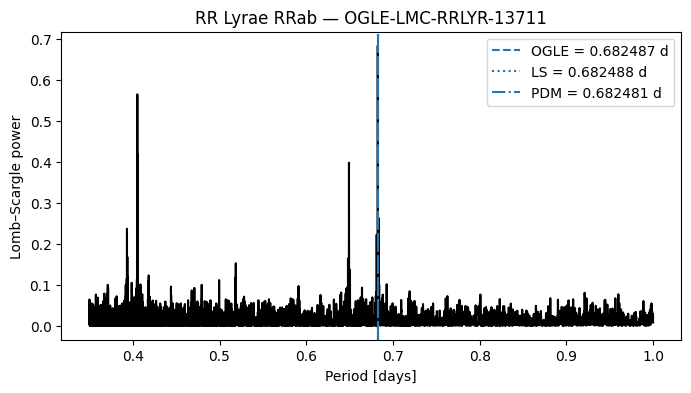

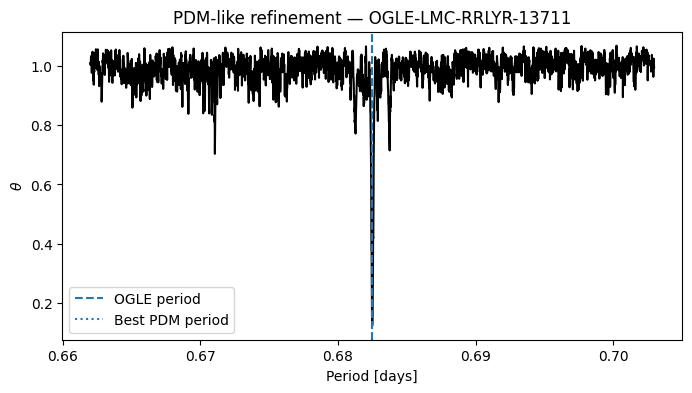

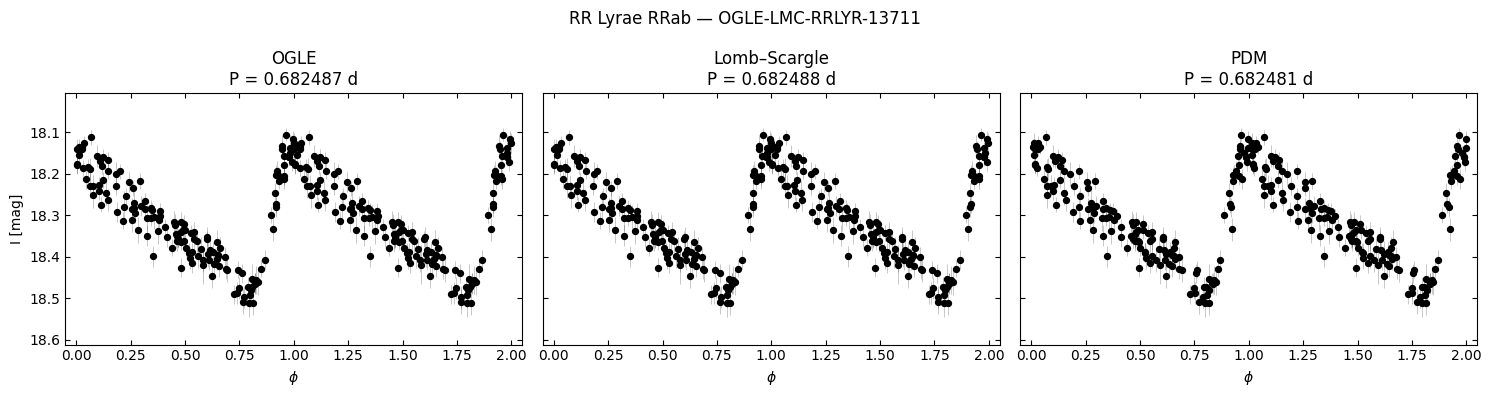

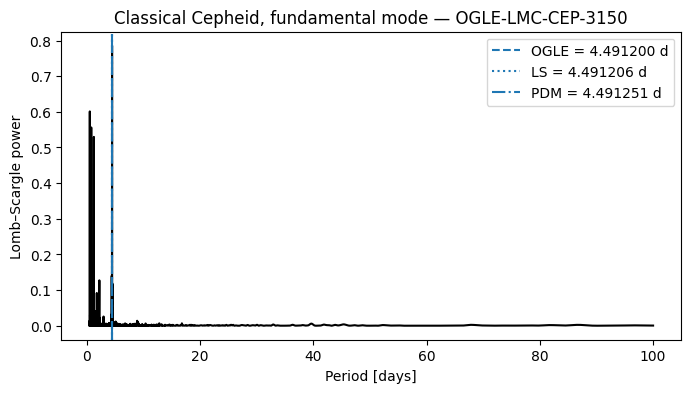

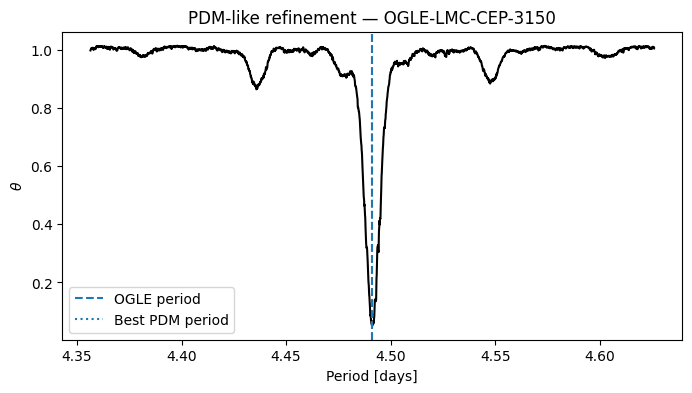

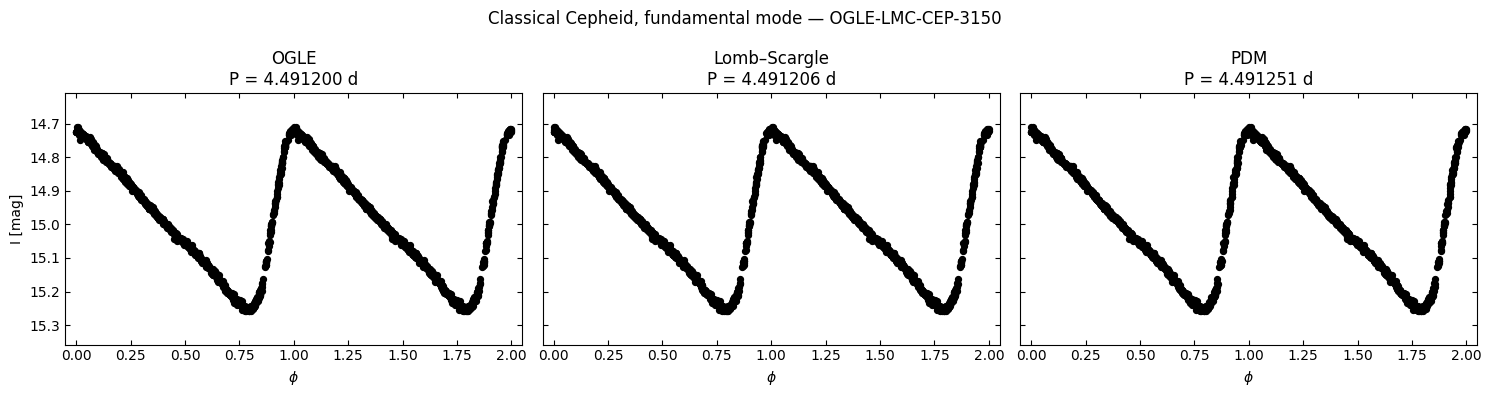

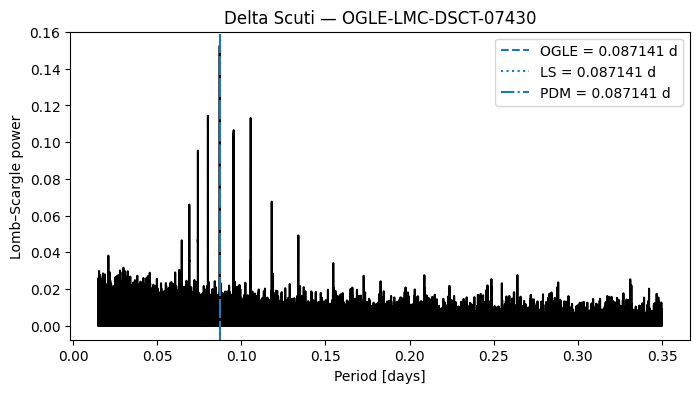

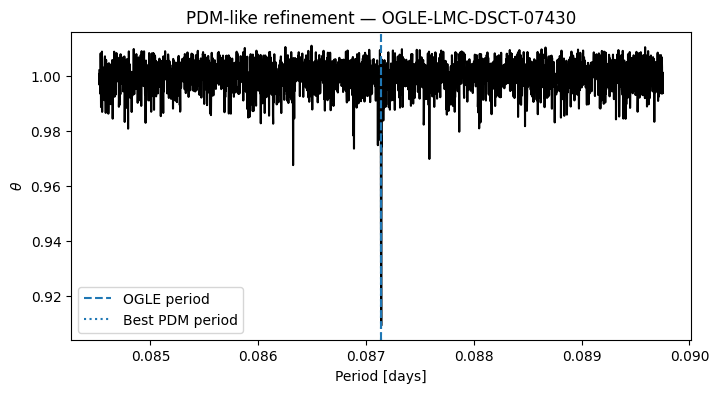

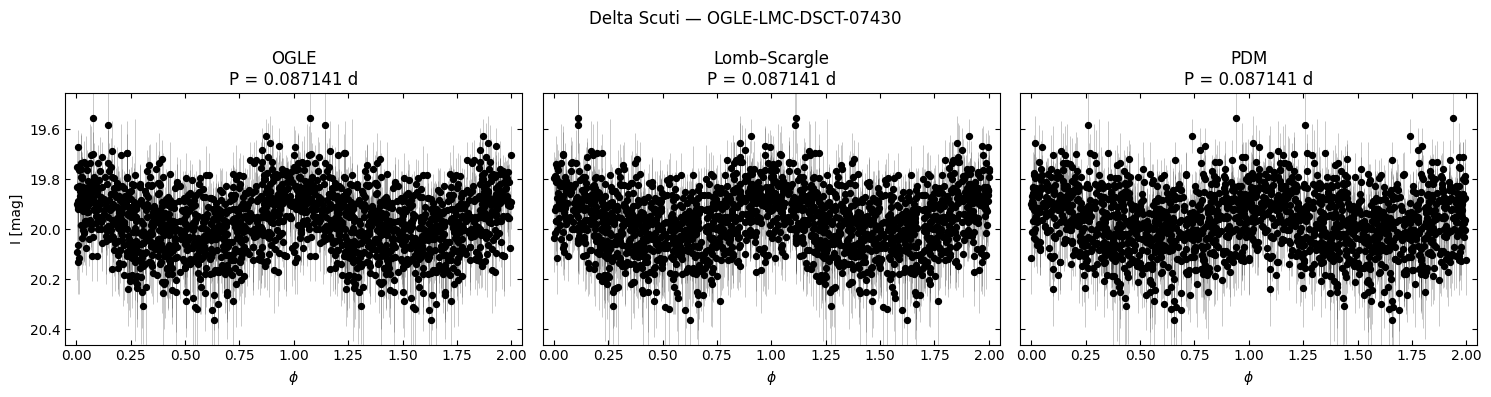

,class,star_id,OGLE_period,LS_period,PDM_period,LS_minus_OGLE,PDM_minus_OGLE
0,RR Lyrae RRab,OGLE-LMC-RRLYR-13711,0.682487,0.682488,0.682481,8.014163e-07,-6.025737e-06
1,"Classical Cepheid, fundamental mode",OGLE-LMC-CEP-3150,4.491200,4.491206,4.491251,6.465678e-06,5.139271e-05
2,Delta Scuti,OGLE-LMC-DSCT-07430,0.087141,0.087141,0.087141,-1.921508e-07,6.795460e-07


In [ ]:
# ============================================================
# EXERCISE 4 — Compare Lomb–Scargle and PDM
# One-cell complete version
# Requires: selected
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from astropy.timeseries import LombScargle

# ------------------------------------------------------------
# Simple PDM-like implementation
# ------------------------------------------------------------

def simple_pdm_theta(df, test_periods, n_bins=12):

    hjd = df["hjd"].to_numpy(dtype=float)
    mag = df["mag"].to_numpy(dtype=float)

    global_var = np.var(mag, ddof=1)

    theta = []

    for P in test_periods:

        phase = ((hjd - hjd.min()) / P) % 1

        bins = np.linspace(0, 1, n_bins + 1)

        numerator = 0.0
        denominator = 0

        for i in range(n_bins):

            mask = (phase >= bins[i]) & (phase < bins[i + 1])

            mag_bin = mag[mask]

            if len(mag_bin) > 1:

                numerator += (
                    (len(mag_bin) - 1)
                    * np.var(mag_bin, ddof=1)
                )

                denominator += len(mag_bin) - 1

        if denominator > 0 and global_var > 0:
            theta.append(
                numerator / denominator / global_var
            )
        else:
            theta.append(np.nan)

    return np.array(theta)


# ------------------------------------------------------------
# Loop over stars
# ------------------------------------------------------------

comparison_rows = []

for star in selected:

    df = star["df"]

    # --------------------------------------------------------
    # Lomb–Scargle
    # --------------------------------------------------------

    hjd = df["hjd"].to_numpy(dtype=float)
    mag = df["mag"].to_numpy(dtype=float)
    err = df["err"].to_numpy(dtype=float)

    mag_centered = mag - np.mean(mag)

    frequency, power = LombScargle(
        hjd,
        mag_centered,
        err
    ).autopower(
        minimum_frequency=1 / star["max_period"],
        maximum_frequency=1 / star["min_period"],
        samples_per_peak=20
    )

    ls_period = 1 / frequency[np.argmax(power)]

    # --------------------------------------------------------
    # PDM-like refinement
    # --------------------------------------------------------

    pdm_grid = np.linspace(
        ls_period * 0.97,
        ls_period * 1.03,
        3000
    )

    theta = simple_pdm_theta(df, pdm_grid)

    pdm_period = pdm_grid[np.nanargmin(theta)]

    # --------------------------------------------------------
    # Save comparison
    # --------------------------------------------------------

    comparison_rows.append({
        "class": star["label"],
        "star_id": star["star_id"],
        "OGLE_period": star["period_ogle"],
        "LS_period": ls_period,
        "PDM_period": pdm_period,
        "LS_minus_OGLE": ls_period - star["period_ogle"],
        "PDM_minus_OGLE": pdm_period - star["period_ogle"],
    })

    # --------------------------------------------------------
    # Periodogram comparison
    # --------------------------------------------------------

    periods = 1 / frequency
    order = np.argsort(periods)

    fig, ax = plt.subplots(figsize=(8, 4))

    ax.plot(periods[order], power[order], color="black")

    ax.axvline(
        star["period_ogle"],
        linestyle="--",
        label=f"OGLE = {star['period_ogle']:.6f} d"
    )

    ax.axvline(
        ls_period,
        linestyle=":",
        label=f"LS = {ls_period:.6f} d"
    )

    ax.axvline(
        pdm_period,
        linestyle="-.",
        label=f"PDM = {pdm_period:.6f} d"
    )

    ax.set_xlabel("Period [days]")
    ax.set_ylabel("Lomb–Scargle power")

    ax.set_title(
        f"{star['label']} — {star['star_id']}"
    )

    ax.legend()

    plt.show()

    # --------------------------------------------------------
    # PDM theta curve
    # --------------------------------------------------------

    fig, ax = plt.subplots(figsize=(8, 4))

    ax.plot(pdm_grid, theta, color="black")

    ax.axvline(
        star["period_ogle"],
        linestyle="--",
        label="OGLE period"
    )

    ax.axvline(
        pdm_period,
        linestyle=":",
        label="Best PDM period"
    )

    ax.set_xlabel("Period [days]")
    ax.set_ylabel(r"$\theta$")

    ax.set_title(
        f"PDM-like refinement — {star['star_id']}"
    )

    ax.legend()

    plt.show()

    # --------------------------------------------------------
    # Folded light curves
    # --------------------------------------------------------

    fig, axes = plt.subplots(
        1,
        3,
        figsize=(15, 4),
        sharey=True
    )

    methods = [
        ("OGLE", star["period_ogle"]),
        ("Lomb–Scargle", ls_period),
        ("PDM", pdm_period),
    ]

    for ax, (name, period) in zip(axes, methods):

        phase = (
            (hjd - star["epoch_ogle"]) / period
        ) % 1

        idx = np.argsort(phase)

        phase = phase[idx]
        mag_sorted = mag[idx]
        err_sorted = err[idx]

        phase2 = np.concatenate([
            phase,
            phase + 1
        ])

        mag2 = np.concatenate([
            mag_sorted,
            mag_sorted
        ])

        err2 = np.concatenate([
            err_sorted,
            err_sorted
        ])

        ax.scatter(
            phase2,
            mag2,
            s=18,
            color="black"
        )

        ax.errorbar(
            phase2,
            mag2,
            yerr=err2,
            fmt="none",
            ecolor="black",
            alpha=0.25,
            elinewidth=0.6
        )

        ax.set_xlim(-0.05, 2.05)

        ax.set_ylim(
            np.max(mag2) + 0.1,
            np.min(mag2) - 0.1
        )

        ax.set_xlabel(r"$\phi$")

        ax.set_title(
            f"{name}\nP = {period:.6f} d"
        )

        ax.tick_params(
            direction="in",
            bottom=True,
            top=True,
            left=True,
            right=True
        )

    axes[0].set_ylabel("I [mag]")

    plt.suptitle(
        f"{star['label']} — {star['star_id']}"
    )

    plt.tight_layout()

    plt.show()

# ------------------------------------------------------------
# Final comparison table
# ------------------------------------------------------------

exercise4_table = pd.DataFrame(comparison_rows)

display(exercise4_table)

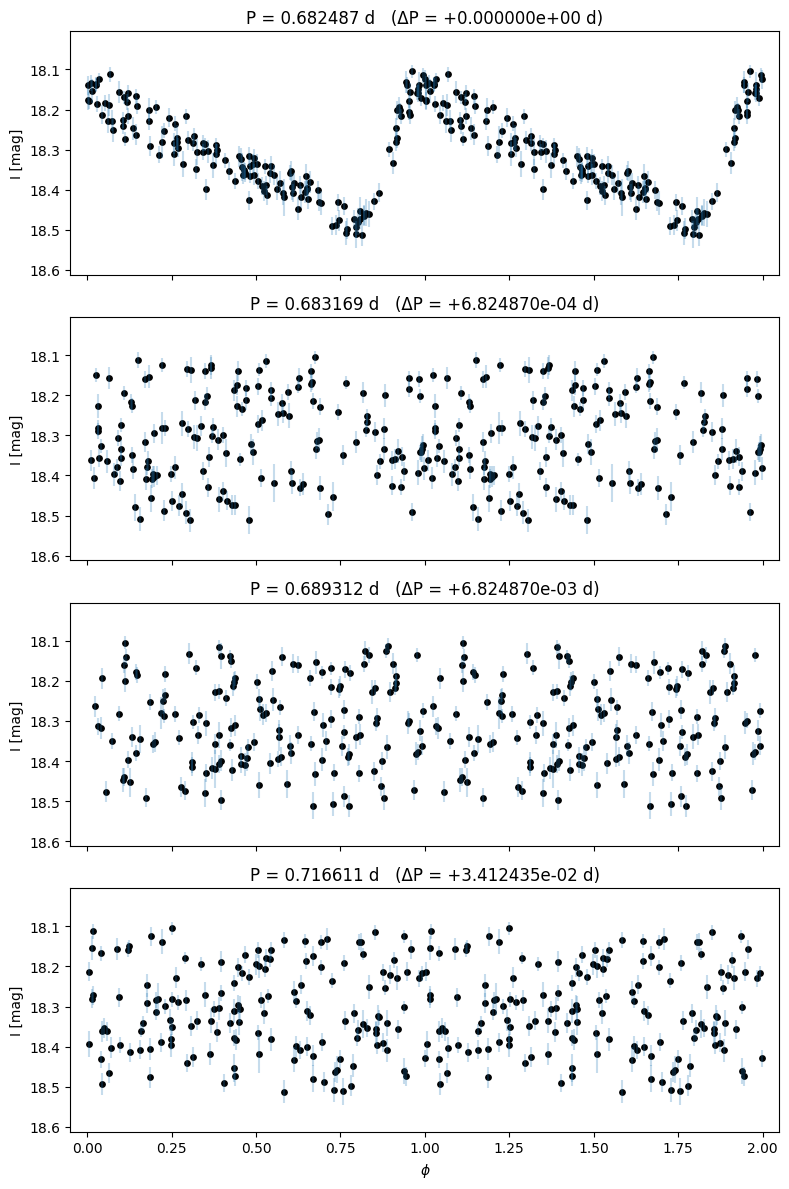

In [36]:
star = selected[0]

df = star["df"]

P_true = star["period_ogle"]

test_periods = [
    P_true,
    P_true * 1.001,
    P_true * 1.01,
    P_true * 1.05,
]

fig, axes = plt.subplots(
    len(test_periods),
    1,
    figsize=(8, 12),
    sharex=True
)

hjd = df["hjd"].to_numpy()
mag = df["mag"].to_numpy()
err = df["err"].to_numpy()

for ax, P in zip(axes, test_periods):

    phase = (
        (hjd - star["epoch_ogle"]) / P
    ) % 1

    idx = np.argsort(phase)

    phase = phase[idx]
    mag_sorted = mag[idx]
    err_sorted = err[idx]

    phase2 = np.concatenate([phase, phase + 1])
    mag2 = np.concatenate([mag_sorted, mag_sorted])
    err2 = np.concatenate([err_sorted, err_sorted])

    ax.scatter(
        phase2,
        mag2,
        s=15,
        color="black"
    )

    ax.errorbar(
        phase2,
        mag2,
        yerr=err2,
        fmt="none",
        alpha=0.25
    )

    ax.set_xlim(-0.05, 2.05)

    ax.set_ylim(
        np.max(mag2) + 0.1,
        np.min(mag2) - 0.1
    )

    delta = P - P_true

    ax.set_title(
        f"P = {P:.6f} d   "
        f"(ΔP = {delta:+.6e} d)"
    )

    ax.set_ylabel("I [mag]")

axes[-1].set_xlabel(r"$\phi$")

plt.tight_layout()
plt.show()

,star_id,period_ogle,amplitude_I,phot_url
0,OGLE-GD-LPV-000001,459.6,3.379,https://astrouw.edu.pl/ogle/ogle4/OCVS/gd/lpv/...
1,OGLE-GD-LPV-000005,339.6,2.682,https://astrouw.edu.pl/ogle/ogle4/OCVS/gd/lpv/...
2,OGLE-GD-LPV-000006,365.8,1.417,https://astrouw.edu.pl/ogle/ogle4/OCVS/gd/lpv/...
3,OGLE-GD-LPV-000009,499.1,4.959,https://astrouw.edu.pl/ogle/ogle4/OCVS/gd/lpv/...
4,OGLE-GD-LPV-000010,313.9,3.748,https://astrouw.edu.pl/ogle/ogle4/OCVS/gd/lpv/...


Selected Mira:
Star ID: OGLE-GD-LPV-000013
OGLE period: 449.3
I amplitude: 1.594
N points: 1278
Baseline: 2500.05994
Observed cycles: 5.564344402403739
URL: https://astrouw.edu.pl/ogle/ogle4/OCVS/gd/lpv/phot_ogle4/I/OGLE-GD-LPV-000013.dat


,star_id,period_ogle,amplitude_I,phot_url,N_points,baseline_days,n_cycles,median_err
0,OGLE-GD-LPV-000013,449.3,1.594,https://astrouw.edu.pl/ogle/ogle4/OCVS/gd/lpv/...,1278,2500.05994,5.564344,0.005
1,OGLE-GD-LPV-000006,365.8,1.417,https://astrouw.edu.pl/ogle/ogle4/OCVS/gd/lpv/...,300,2491.10548,6.810020,0.006
2,OGLE-GD-LPV-000001,459.6,3.379,https://astrouw.edu.pl/ogle/ogle4/OCVS/gd/lpv/...,300,2491.10548,5.420160,0.006
3,OGLE-GD-LPV-000005,339.6,2.682,https://astrouw.edu.pl/ogle/ogle4/OCVS/gd/lpv/...,297,2491.10546,7.335411,0.005
4,OGLE-GD-LPV-000009,499.1,4.959,https://astrouw.edu.pl/ogle/ogle4/OCVS/gd/lpv/...,297,2491.10546,4.991195,0.007
5,OGLE-GD-LPV-000017,293.2,1.616,https://astrouw.edu.pl/ogle/ogle4/OCVS/gd/lpv/...,295,2489.12784,8.489522,0.009
6,OGLE-GD-LPV-000016,430.0,2.844,https://astrouw.edu.pl/ogle/ogle4/OCVS/gd/lpv/...,295,2489.12784,5.788669,0.041
7,OGLE-GD-LPV-000018,436.2,4.457,https://astrouw.edu.pl/ogle/ogle4/OCVS/gd/lpv/...,292,2489.12784,5.706391,0.008
8,OGLE-GD-LPV-000010,313.9,3.748,https://astrouw.edu.pl/ogle/ogle4/OCVS/gd/lpv/...,281,2489.12840,7.929686,0.007
9,OGLE-GD-LPV-000014,346.1,1.192,https://astrouw.edu.pl/ogle/ogle4/OCVS/gd/lpv/...,237,2486.20637,7.183491,0.009


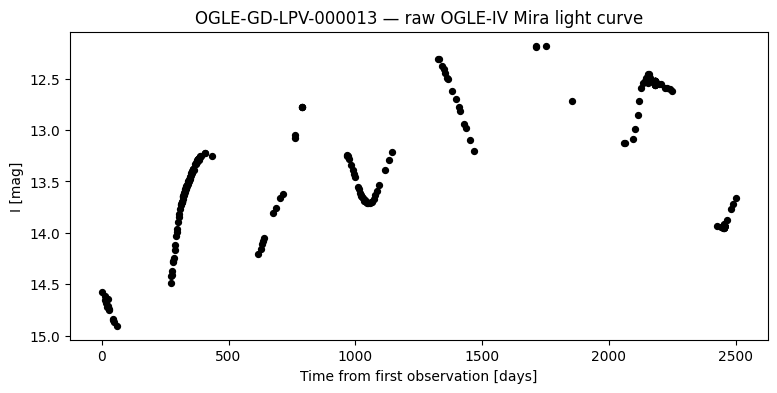

,star_id,N_points,baseline_days,median_cadence_days,mean_cadence_days,max_gap_days,OGLE_period_days,observed_cycles
0,OGLE-GD-LPV-000013,1278,2500.05994,0.00133,1.95776,245.36179,449.3,5.564344


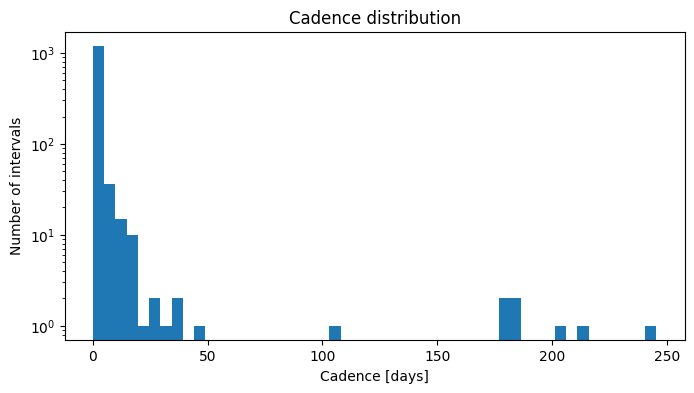

OGLE period: 449.3
Lomb-Scargle period: 793.654720106691
Difference: 344.354720106691


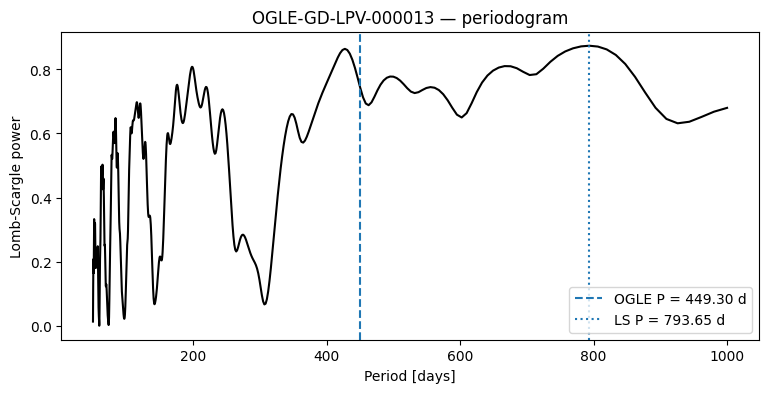

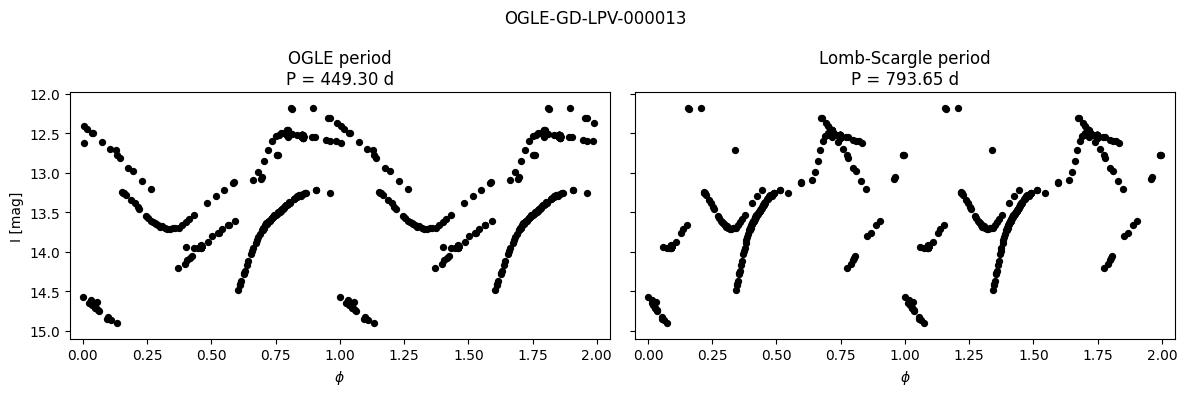

,star_id,N_points,baseline_days,observed_cycles,OGLE_period_days,LS_period_days,difference_days,relative_difference,phot_url
0,OGLE-GD-LPV-000013,1278,2500.05994,5.564344,449.3,793.65472,344.35472,0.766425,https://astrouw.edu.pl/ogle/ogle4/OCVS/gd/lpv/...


In [41]:
# ============================================================
# EXERCISE 5 — Mira stars / Long-period variables
# Working one-cell version using OGLE-IV Galactic Disk Miras
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from urllib.request import urlopen
from io import StringIO
from astropy.timeseries import LombScargle

# ------------------------------------------------------------
# Correct OGLE-IV Mira directory
# ------------------------------------------------------------

CATALOG_URL = "https://astrouw.edu.pl/ogle/ogle4/OCVS/gd/lpv/Miras.dat"
PHOT_BASE_URL = "https://astrouw.edu.pl/ogle/ogle4/OCVS/gd/lpv/phot_ogle4/I"

MIN_PERIOD = 50
MAX_PERIOD = 1000

# ------------------------------------------------------------
# Read catalog
# ------------------------------------------------------------

txt = urlopen(CATALOG_URL).read().decode()
lines = [line for line in txt.splitlines() if line.strip()]

records = []

for line in lines:
    try:
        star_id = line[0:18].strip()
        period = float(line[34:43])
        amp = float(line[44:49])
        phot_url = f"{PHOT_BASE_URL}/{star_id}.dat"

        records.append({
            "star_id": star_id,
            "period_ogle": period,
            "amplitude_I": amp,
            "phot_url": phot_url
        })

    except:
        continue

catalog = pd.DataFrame(records)

display(catalog.head())

# ------------------------------------------------------------
# Choose a Mira with good sampling
# ------------------------------------------------------------

candidates = []

for _, row in catalog.head(200).iterrows():

    try:
        df = pd.read_csv(
            row["phot_url"],
            sep=r"\s+",
            names=["hjd", "mag", "err"],
            comment="#"
        )

        df = df.dropna()
        df = df.sort_values("hjd").reset_index(drop=True)

        if len(df) < 80:
            continue

        baseline = df["hjd"].max() - df["hjd"].min()
        n_cycles = baseline / row["period_ogle"]

        if n_cycles < 2:
            continue

        candidates.append({
            "star_id": row["star_id"],
            "period_ogle": row["period_ogle"],
            "amplitude_I": row["amplitude_I"],
            "phot_url": row["phot_url"],
            "N_points": len(df),
            "baseline_days": baseline,
            "n_cycles": n_cycles,
            "median_err": np.median(df["err"]),
            "df": df
        })

    except:
        continue

if len(candidates) == 0:
    raise RuntimeError("No usable Mira found in the first 200 catalog entries.")

candidates = sorted(
    candidates,
    key=lambda x: (x["N_points"], x["n_cycles"]),
    reverse=True
)

mira = candidates[0]
df = mira["df"]

print("Selected Mira:")
print("Star ID:", mira["star_id"])
print("OGLE period:", mira["period_ogle"])
print("I amplitude:", mira["amplitude_I"])
print("N points:", mira["N_points"])
print("Baseline:", mira["baseline_days"])
print("Observed cycles:", mira["n_cycles"])
print("URL:", mira["phot_url"])

display(pd.DataFrame(candidates).drop(columns=["df"]).head(10))

# ------------------------------------------------------------
# Raw light curve
# ------------------------------------------------------------

hjd = df["hjd"].to_numpy(dtype=float)
mag = df["mag"].to_numpy(dtype=float)
err = df["err"].to_numpy(dtype=float)

plt.figure(figsize=(9, 4))
plt.scatter(hjd - hjd.min(), mag, s=18, color="black")
plt.gca().invert_yaxis()
plt.xlabel("Time from first observation [days]")
plt.ylabel("I [mag]")
plt.title(f"{mira['star_id']} — raw OGLE-IV Mira light curve")
plt.show()

# ------------------------------------------------------------
# Cadence
# ------------------------------------------------------------

cadence = np.diff(np.sort(hjd))

cadence_table = pd.DataFrame([{
    "star_id": mira["star_id"],
    "N_points": len(hjd),
    "baseline_days": hjd.max() - hjd.min(),
    "median_cadence_days": np.median(cadence),
    "mean_cadence_days": np.mean(cadence),
    "max_gap_days": np.max(cadence),
    "OGLE_period_days": mira["period_ogle"],
    "observed_cycles": (hjd.max() - hjd.min()) / mira["period_ogle"]
}])

display(cadence_table)

plt.figure(figsize=(8, 4))
plt.hist(cadence, bins=50)
plt.yscale("log")
plt.xlabel("Cadence [days]")
plt.ylabel("Number of intervals")
plt.title("Cadence distribution")
plt.show()

# ------------------------------------------------------------
# Lomb-Scargle period
# ------------------------------------------------------------

mag_centered = mag - np.mean(mag)

frequency, power = LombScargle(hjd, mag_centered, err).autopower(
    minimum_frequency=1 / MAX_PERIOD,
    maximum_frequency=1 / MIN_PERIOD,
    samples_per_peak=20
)

ls_period = 1 / frequency[np.argmax(power)]

print("OGLE period:", mira["period_ogle"])
print("Lomb-Scargle period:", ls_period)
print("Difference:", ls_period - mira["period_ogle"])

periods = 1 / frequency
order = np.argsort(periods)

plt.figure(figsize=(9, 4))
plt.plot(periods[order], power[order], color="black")
plt.axvline(mira["period_ogle"], linestyle="--", label=f"OGLE P = {mira['period_ogle']:.2f} d")
plt.axvline(ls_period, linestyle=":", label=f"LS P = {ls_period:.2f} d")
plt.xlabel("Period [days]")
plt.ylabel("Lomb-Scargle power")
plt.title(f"{mira['star_id']} — periodogram")
plt.legend()
plt.show()

# ------------------------------------------------------------
# Folded light curves
# ------------------------------------------------------------
# Miras.dat does not provide T0 in this catalog format.
# For visual folding, use first observation as reference epoch.

T0 = hjd.min()

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

for ax, P, label in zip(
    axes,
    [mira["period_ogle"], ls_period],
    ["OGLE period", "Lomb-Scargle period"]
):

    phase = ((hjd - T0) / P) % 1
    idx = np.argsort(phase)

    phase = phase[idx]
    mag_sorted = mag[idx]
    err_sorted = err[idx]

    phase2 = np.concatenate([phase, phase + 1])
    mag2 = np.concatenate([mag_sorted, mag_sorted])
    err2 = np.concatenate([err_sorted, err_sorted])

    ax.scatter(phase2, mag2, s=18, color="black")
    ax.errorbar(
        phase2,
        mag2,
        yerr=err2,
        fmt="none",
        ecolor="black",
        alpha=0.25,
        elinewidth=0.6
    )

    ax.set_xlim(-0.05, 2.05)
    ax.set_ylim(np.max(mag2) + 0.2, np.min(mag2) - 0.2)
    ax.set_xlabel(r"$\phi$")
    ax.set_title(f"{label}\nP = {P:.2f} d")

axes[0].set_ylabel("I [mag]")
plt.suptitle(mira["star_id"])
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Summary
# ------------------------------------------------------------

summary = pd.DataFrame([{
    "star_id": mira["star_id"],
    "N_points": len(hjd),
    "baseline_days": hjd.max() - hjd.min(),
    "observed_cycles": (hjd.max() - hjd.min()) / mira["period_ogle"],
    "OGLE_period_days": mira["period_ogle"],
    "LS_period_days": ls_period,
    "difference_days": ls_period - mira["period_ogle"],
    "relative_difference": (ls_period - mira["period_ogle"]) / mira["period_ogle"],
    "phot_url": mira["phot_url"]
}])

display(summary)